In [1]:
# Imports
import numpy as np
import math
from collections import deque
from sklearn.datasets import load_iris
import os, sys
# add src to path for importing rice_ml package
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../../src')))
from rice_ml.unsupervised_learning.dbscan import dbscan
from rice_ml.unsupervised_learning.k_means_clustering import kmeans
np.random.seed(42)

## 1. Load Iris Dataset
We use the classic Iris dataset via `sklearn.datasets.load_iris()`.

In [2]:
# Load Iris data (150 samples, 4 features, 3 classes)
iris = load_iris()
X_raw = iris.data.astype(float)
X_raw[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

## 2. Preprocessing
We standardize features (z-score) so algorithms are scale-invariant.

In [3]:
def zscore_standardize(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return (X - mean) / std, mean, std

X, mean, std = zscore_standardize(X_raw)
X.shape, X[:3]

((150, 4),
 array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
        [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
        [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ]]))

## 3. Helper Functions
Distance computations and utility helpers.

In [7]:
def pairwise_distances(X):
    # Euclidean pairwise distance matrix
    # Efficient via (x - y)^2 = x^2 + y^2 - 2xy
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = sq + sq.T - 2 * (X @ X.T)
    D2 = np.maximum(D2, 0.0)
    return np.sqrt(D2)

def neighbors_within_eps(D, i, eps):
    return np.where(D[i] <= eps)[0]

## 4. DBSCAN

In [4]:
# Run DBSCAN from source on standardized Iris
# eps/min_samples may need tuning for Iris feature scale
# Using eps=0.6, min_samples=6 as a starting point

db_labels, db_n_clusters = dbscan(X, eps=0.6, min_samples=6)
db_n_clusters, np.bincount(np.where(db_labels>=0, db_labels, 0))

(2, array([75, 75]))

## 5. K-Means

In [5]:
# Run K-Means from source on standardized Iris
km_labels, km_centers = kmeans(X, k=3)
km_centers, np.bincount(km_labels)

(array([[-0.01139555, -0.87600831,  0.37707573,  0.31115341],
        [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
        [ 1.16743407,  0.14530299,  1.00302557,  1.0300019 ]]),
 array([56, 50, 44]))

## 6. Comparison Metrics
We'll compute simple internal metrics: silhouette-like score approximation and cluster counts.

In [8]:
def average_intra_cluster_distance(X, labels):
    # average distance of each point to its cluster members
    D = pairwise_distances(X)
    clusters = np.unique(labels[labels >= 0])
    vals = []
    for c in clusters:
        idx = np.where(labels == c)[0]
        if idx.size <= 1:
            vals.append(0.0)
        else:
            sub = D[np.ix_(idx, idx)]
            vals.append(np.mean(sub))
    return np.mean(vals) if vals else float('inf')

def average_inter_cluster_center_distance(centers):
    if centers is None or len(centers) <= 1:
        return 0.0
    D = pairwise_distances(centers)
    # upper triangle mean excluding diagonal
    triu = D[np.triu_indices(D.shape[0], 1)]
    return triu.mean()

db_intra = average_intra_cluster_distance(X, db_labels)
km_intra = average_intra_cluster_distance(X, km_labels)
km_inter = average_inter_cluster_center_distance(km_centers)
print('DBSCAN: clusters =', len(np.unique(db_labels[db_labels>=0])), 'intra =', round(db_intra,3), 'noise =', np.sum(db_labels==-1))
print('K-Means: clusters =', len(np.unique(km_labels)), 'intra =', round(km_intra,3), 'inter =', round(km_inter,3))

DBSCAN: clusters = 2 intra = 1.139 noise = 29
K-Means: clusters = 3 intra = 1.207 inter = 2.95


## 7. Visualizations
We visualize clusters on the first two standardized features for both methods, and show K-Means centers.

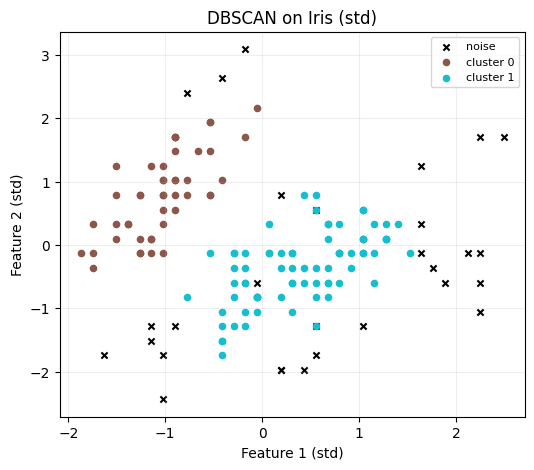

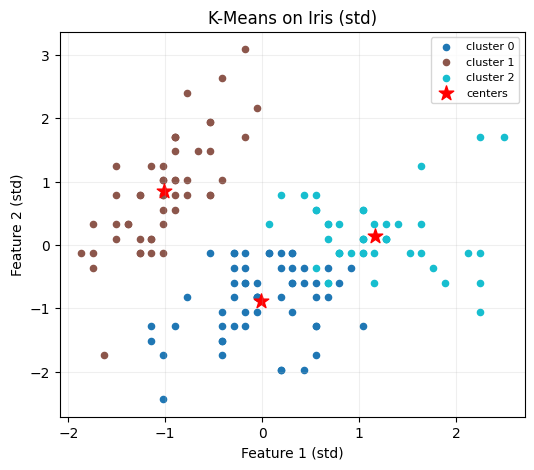

In [9]:
# Scatter plots for DBSCAN and K-Means (first two features)
import matplotlib.pyplot as plt
import numpy as np

def plot_clusters(X, labels, title, centers=None):
    # Only use first two standardized features for 2D visualization
    X2 = X[:, :2]
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
    plt.figure(figsize=(6, 5))
    for idx, c in enumerate(unique_labels):
        mask = labels == c
        if c == -1:
            plt.scatter(X2[mask, 0], X2[mask, 1], s=20, c='k', marker='x', label='noise')
        else:
            plt.scatter(X2[mask, 0], X2[mask, 1], s=20, color=colors[idx], label=f'cluster {int(c)}')
    if centers is not None:
        C2 = centers[:, :2]
        plt.scatter(C2[:, 0], C2[:, 1], s=120, c='red', marker='*', label='centers')
    plt.title(title)
    plt.legend(loc='best', fontsize=8)
    plt.xlabel('Feature 1 (std)')
    plt.ylabel('Feature 2 (std)')
    plt.grid(alpha=0.2)
    plt.show()

plot_clusters(X, db_labels, title='DBSCAN on Iris (std)')
plot_clusters(X, km_labels, title='K-Means on Iris (std)', centers=km_centers)

## 9. Interpretation: DBSCAN vs K-Means
The scatter plots above use only the first two standardized features for visualization, while both algorithms operate on all four standardized features. The different outcomes arise from each method's assumptions and objective.

- DBSCAN: density-based. With `eps=0.6` and `min_samples=6`, it finds two dense groups and labels sparse/outlying points as noise. In Iris, the tight Setosa group forms one cluster, while Versicolor and Virginica overlap in feature space and are often merged into a single dense region. DBSCAN can mark boundary points as noise when local density is low.
- K-Means: variance-based. It partitions data into `k=3` compact (roughly spherical) clusters by minimizing within-cluster squared distance. It does not produce noise; every point belongs to a cluster. On Iris, K-Means typically isolates Setosa and splits the overlapping Versicolor/Virginica points into two centers to reduce variance.